# Task 03 — Feature Engineering Mastery

## Objective

The objective of this task is to apply advanced feature engineering techniques to the House Prices dataset and improve house price prediction performance.

The task focuses on creating meaningful features, transforming existing features, selecting relevant features, and evaluating their impact on model performance.

## 1. Setup and Data Loading

The required Python libraries are imported for data manipulation, visualization, preprocessing, feature engineering, feature selection, and model evaluation.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression, RFE
from sklearn.linear_model import LinearRegression, Lasso

In [2]:
df = pd.read_csv("House Prices.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (1460, 81)


In [3]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1460
Columns: 81


### Initial Dataset Understanding

The dataset contains residential property information that can be used to predict house sale prices. It includes numerical and categorical variables describing property size, quality, age, location-related characteristics, rooms, garages, and other attributes.

The target variable for this task is `SalePrice`.

In [7]:
print("Target variable: SalePrice")
print("Missing SalePrice values:", df["SalePrice"].isnull().sum())
print("Unique SalePrice values:", df["SalePrice"].nunique())

Target variable: SalePrice
Missing SalePrice values: 0
Unique SalePrice values: 663


In [8]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("Columns with missing values:")
print(missing)

Columns with missing values:
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


## 2. Missing Value Analysis and Treatment

Missing values were analyzed according to the meaning of each feature. In this dataset, some missing values represent the absence of a property feature, such as no pool, garage, basement, or fence. These values are therefore treated differently from genuinely unknown values.

Categorical features representing the absence of a property component are filled with "None", while numerical features representing absent components are filled with 0. Other missing numerical and categorical values are handled using appropriate statistical imputation.

In [9]:
# Categorical features where NaN means the feature is absent
none_columns = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "MasVnrType",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "BsmtExposure",
    "BsmtQual",
    "BsmtCond",
    "BsmtFinType1",
    "BsmtFinType2"
]

# Replace missing categorical values with "None"
for col in none_columns:
    df[col] = df[col].fillna("None")

print("Categorical absence-related missing values handled.")

Categorical absence-related missing values handled.


In [10]:
zero_columns = [
    "GarageYrBlt",
    "MasVnrArea"
]

for col in zero_columns:
    df[col] = df[col].fillna(0)

print("Numerical absence-related missing values handled.")

Numerical absence-related missing values handled.


In [11]:
df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage"].median())

In [12]:
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])

In [13]:
missing_after = df.isnull().sum()
missing_after = missing_after[missing_after > 0].sort_values(ascending=False)

print("Remaining missing values:")
print(missing_after)

Remaining missing values:
Series([], dtype: int64)


## 3. Data Quality Validation

Before building the baseline model, the cleaned dataset is checked for duplicate records and target validity.

In [14]:
print("Duplicate rows:", df.duplicated().sum())
print("Missing SalePrice values:", df["SalePrice"].isnull().sum())
print("Dataset shape:", df.shape)

Duplicate rows: 0
Missing SalePrice values: 0
Dataset shape: (1460, 81)


In [15]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1460, 80)
Target shape: (1460,)


## 4. Baseline Model

A simple baseline model is created before advanced feature engineering. This provides a reference MAE against which the engineered model can later be compared.

The data is split into training and testing sets before fitting preprocessing steps to prevent data leakage.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (1168, 80)
Testing set: (292, 80)


In [17]:
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# Make train and test columns identical
X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded,
    join="left",
    axis=1,
    fill_value=0
)

# Fill any remaining numerical missing values using training medians
train_medians = X_train_encoded.median()

X_train_encoded = X_train_encoded.fillna(train_medians)
X_test_encoded = X_test_encoded.fillna(train_medians)

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded testing shape:", X_test_encoded.shape)

Encoded training shape: (1168, 258)
Encoded testing shape: (292, 258)


In [19]:
baseline_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

baseline_model.fit(X_train_encoded, y_train)

baseline_predictions = baseline_model.predict(X_test_encoded)

baseline_mae = mean_absolute_error(y_test, baseline_predictions)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_predictions))
baseline_r2 = r2_score(y_test, baseline_predictions)

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline R²:", baseline_r2)

Baseline MAE: 17784.57205479452
Baseline RMSE: 29477.216934898577
Baseline R²: 0.8867184661047528


## Baseline Evaluation

A Random Forest Regressor was used as the baseline model because house prices can have nonlinear relationships with property characteristics.

The baseline model achieved an MAE of approximately $17,784.57, which is already below the business target of $18,000. The R² score of 0.8867 indicates that the model explains a substantial portion of the variation in house prices.

This baseline will be used as the reference point for evaluating the impact of feature engineering.

## 5. Domain-Driven Feature Creation

Domain knowledge was used to create meaningful features from existing variables. The engineered features represent concepts that are directly relevant to residential property value, such as total living area, total bathrooms, and property age at the time of sale.

In [20]:
df_fe = df.copy()

# Total living area
df_fe["TotalSF"] = (
    df_fe["TotalBsmtSF"]
    + df_fe["1stFlrSF"]
    + df_fe["2ndFlrSF"]
)

# Total bathrooms
df_fe["TotalBath"] = (
    df_fe["FullBath"]
    + 0.5 * df_fe["HalfBath"]
    + df_fe["BsmtFullBath"]
    + 0.5 * df_fe["BsmtHalfBath"]
)

# House age at the time of sale
df_fe["HouseAge"] = df_fe["YrSold"] - df_fe["YearBuilt"]

# Years since last remodeling
df_fe["RemodAge"] = df_fe["YrSold"] - df_fe["YearRemodAdd"]

# Total porch area
df_fe["TotalPorchSF"] = (
    df_fe["OpenPorchSF"]
    + df_fe["3SsnPorch"]
    + df_fe["EnclosedPorch"]
    + df_fe["ScreenPorch"]
    + df_fe["WoodDeckSF"]
)

print("New features created successfully.")

New features created successfully.


In [22]:
new_features = [
    "TotalSF",
    "TotalBath",
    "HouseAge",
    "RemodAge",
    "TotalPorchSF"
]

df_fe[new_features].head()

,TotalSF,TotalBath,HouseAge,RemodAge,TotalPorchSF
0,2566,3.5,5,5,61
1,2524,2.5,31,31,298
2,2706,3.5,7,6,42
3,2473,2.0,91,36,307
4,3343,3.5,8,8,276


## 6. Feature Relationship Analysis

The newly created features are examined to understand their relationship with the target variable. Strong relationships can indicate potentially useful features for house price prediction.

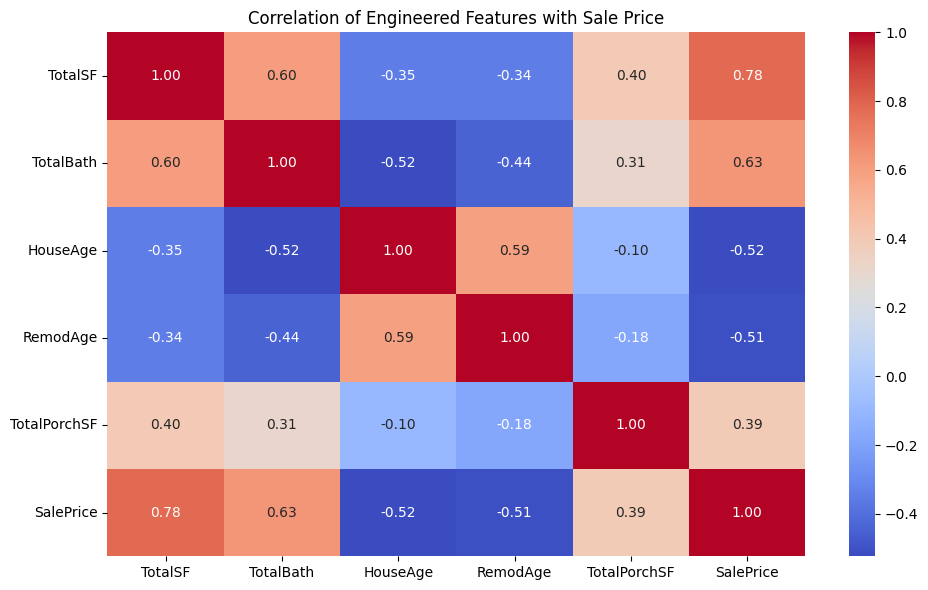

In [23]:
correlation_features = new_features + ["SalePrice"]

correlation_matrix = df_fe[correlation_features].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation of Engineered Features with Sale Price")
plt.tight_layout()
plt.show()

## 7. Polynomial Feature Engineering

Polynomial features are created from selected numerical features to capture nonlinear relationships and interactions between property characteristics. A degree-2 transformation is used to control the number of generated features and reduce unnecessary complexity.

In [24]:
poly_features = [
    "TotalSF",
    "TotalBath",
    "HouseAge",
    "RemodAge"
]

poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

poly_data = poly.fit_transform(df_fe[poly_features])

poly_feature_names = poly.get_feature_names_out(poly_features)

poly_df = pd.DataFrame(
    poly_data,
    columns=poly_feature_names,
    index=df_fe.index
)

print("Original selected features:", len(poly_features))
print("Polynomial features created:", len(poly_feature_names))

poly_df.head()

Original selected features: 4
Polynomial features created: 14


,TotalSF,TotalBath,HouseAge,RemodAge,TotalSF^2,TotalSF TotalBath,TotalSF HouseAge,TotalSF RemodAge,TotalBath^2,TotalBath HouseAge,TotalBath RemodAge,HouseAge^2,HouseAge RemodAge,RemodAge^2
0,2566.0,3.5,5.0,5.0,6584356.0,8981.0,12830.0,12830.0,12.25,17.5,17.5,25.0,25.0,25.0
1,2524.0,2.5,31.0,31.0,6370576.0,6310.0,78244.0,78244.0,6.25,77.5,77.5,961.0,961.0,961.0
2,2706.0,3.5,7.0,6.0,7322436.0,9471.0,18942.0,16236.0,12.25,24.5,21.0,49.0,42.0,36.0
3,2473.0,2.0,91.0,36.0,6115729.0,4946.0,225043.0,89028.0,4.00,182.0,72.0,8281.0,3276.0,1296.0
4,3343.0,3.5,8.0,8.0,11175649.0,11700.5,26744.0,26744.0,12.25,28.0,28.0,64.0,64.0,64.0


## 8. Binning Continuous Features

Binning converts continuous numerical variables into meaningful intervals. For this task, house age is grouped into interpretable age categories to capture different stages of property life cycle.

In [25]:
df_fe["HouseAgeGroup"] = pd.cut(
    df_fe["HouseAge"],
    bins=[-1, 10, 30, 60, np.inf],
    labels=["New", "Mid-Age", "Old", "Very Old"]
)

print(df_fe["HouseAgeGroup"].value_counts().sort_index())

HouseAgeGroup
New         434
Mid-Age     208
Old         526
Very Old    292
Name: count, dtype: int64


In [26]:
df_fe[["HouseAge", "HouseAgeGroup"]].head(10)

,HouseAge,HouseAgeGroup
0,5,New
1,31,Old
2,7,New
3,91,Very Old
4,8,New
5,16,Mid-Age
6,3,New
7,36,Old
8,77,Very Old
9,69,Very Old


## 9. Target Encoding

Target encoding converts categorical variables into numerical values based on the mean target value for each category. To prevent data leakage, the encoding mapping is learned only from the training data and then applied to the test data.

In [27]:
X_fe = df_fe.drop("SalePrice", axis=1)
y_fe = df_fe["SalePrice"]

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe,
    y_fe,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train_fe.shape)
print("Testing set:", X_test_fe.shape)

Training set: (1168, 86)
Testing set: (292, 86)


In [28]:
target_column = "Neighborhood"

target_means = y_train_fe.groupby(
    X_train_fe[target_column]
).mean()

global_mean = y_train_fe.mean()

X_train_fe["Neighborhood_TargetEncoded"] = (
    X_train_fe[target_column].map(target_means)
)

X_test_fe["Neighborhood_TargetEncoded"] = (
    X_test_fe[target_column].map(target_means)
)

# Handle categories that appear only in test data
X_train_fe["Neighborhood_TargetEncoded"] = (
    X_train_fe["Neighborhood_TargetEncoded"].fillna(global_mean)
)

X_test_fe["Neighborhood_TargetEncoded"] = (
    X_test_fe["Neighborhood_TargetEncoded"].fillna(global_mean)
)

print(X_train_fe[[
    "Neighborhood",
    "Neighborhood_TargetEncoded"
]].head())

     Neighborhood  Neighborhood_TargetEncoded
254         NAmes               147408.204420
1066      Gilbert               196540.646154
638       Edwards               127908.850575
799         SWISU               144823.047619
380         SWISU               144823.047619


## 10. Feature Selection Using Mutual Information

Mutual Information is used to identify features that contain useful information about SalePrice. It can capture both linear and nonlinear dependencies between features and the target. The highest-scoring features will be considered for the final modeling pipeline.

In [30]:
from sklearn.feature_selection import mutual_info_regression

# Select numerical features only
X_mi = X_train_fe.select_dtypes(include=np.number).copy()

# Fill any remaining missing values
X_mi = X_mi.fillna(X_mi.median())

mi_scores = mutual_info_regression(
    X_mi,
    y_train_fe,
    random_state=42
)

mi_results = pd.DataFrame({
    "Feature": X_mi.columns,
    "Mutual_Information": mi_scores
}).sort_values(
    "Mutual_Information",
    ascending=False
)

mi_results.head(15)

,Feature,Mutual_Information
37,TotalSF,0.637224
4,OverallQual,0.524901
42,Neighborhood_TargetEncoded,0.470768
16,GrLivArea,0.454140
27,GarageArea,0.365062
26,GarageCars,0.353699
12,TotalBsmtSF,0.345827
6,YearBuilt,0.341158
38,TotalBath,0.328404
39,HouseAge,0.326290


## 11. Feature Selection Using RFE

Recursive Feature Elimination (RFE) is used to select a subset of important features based on model performance. RFE repeatedly fits a model, removes the least important features, and continues until the desired number of features remains.

In [31]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor

# Use numerical training features
X_rfe = X_train_fe.select_dtypes(include=np.number).copy()

# Fill missing values using training medians
X_rfe = X_rfe.fillna(X_rfe.median())

print("Features available for RFE:", X_rfe.shape[1])

Features available for RFE: 43


In [33]:
rfe_estimator = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rfe = RFE(
    estimator=rfe_estimator,
    n_features_to_select=15,
    step=1
)

rfe.fit(X_rfe, y_train_fe)

RFE(estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
    n_features_to_select=15)

In [34]:
rfe_results = pd.DataFrame({
    "Feature": X_rfe.columns,
    "Selected": rfe.support_,
    "Ranking": rfe.ranking_
}).sort_values(
    ["Selected", "Ranking"],
    ascending=[False, True]
)

rfe_results

,Feature,Selected,Ranking
2,LotFrontage,True,1
3,LotArea,True,1
4,OverallQual,True,1
6,YearBuilt,True,1
7,YearRemodAdd,True,1
9,BsmtFinSF1,True,1
11,BsmtUnfSF,True,1
14,2ndFlrSF,True,1
16,GrLivArea,True,1
27,GarageArea,True,1


In [35]:
selected_rfe_features = X_rfe.columns[rfe.support_].tolist()

print("RFE Selected Features:")
for feature in selected_rfe_features:
    print(feature)

RFE Selected Features:
LotFrontage
LotArea
OverallQual
YearBuilt
YearRemodAdd
BsmtFinSF1
BsmtUnfSF
2ndFlrSF
GrLivArea
GarageArea
TotalSF
TotalBath
RemodAge
TotalPorchSF
Neighborhood_TargetEncoded


## 12. Feature Selection Using L1 Regularization

L1 regularization is used for feature selection by applying a penalty to model coefficients. Less informative features can have their coefficients reduced to zero, allowing the model to retain a smaller set of useful predictors.

In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso

# Use the same numerical feature set used for RFE
X_l1 = X_train_fe.select_dtypes(include=np.number).copy()

# Fill missing values using training medians
X_l1 = X_l1.fillna(X_l1.median())

# Scale features because L1 regularization is sensitive to feature scale
scaler_l1 = StandardScaler()

X_l1_scaled = scaler_l1.fit_transform(X_l1)

print("Features available for L1:", X_l1.shape[1])

Features available for L1: 43


In [37]:
lasso = Lasso(
    alpha=0.01,
    max_iter=10000,
    random_state=42
)

lasso.fit(X_l1_scaled, y_train_fe)

l1_results = pd.DataFrame({
    "Feature": X_l1.columns,
    "Coefficient": lasso.coef_
})

l1_results["Absolute_Coefficient"] = (
    l1_results["Coefficient"].abs()
)

l1_results = l1_results.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

l1_results.head(20)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.353e+11, tolerance: 6.967e+08
  model = cd_fast.enet_coordinate_descent(


,Feature,Coefficient,Absolute_Coefficient
14,2ndFlrSF,22725.346043,22725.346043
6,YearBuilt,22013.760608,22013.760608
13,1stFlrSF,20861.533327,20861.533327
42,Neighborhood_TargetEncoded,18654.513846,18654.513846
4,OverallQual,18556.076533,18556.076533
39,HouseAge,16180.919960,16180.919960
37,TotalSF,-15257.295101,15257.295101
9,BsmtFinSF1,10871.567364,10871.567364
26,GarageCars,9642.524956,9642.524956
23,TotRmsAbvGrd,8475.889075,8475.889075


In [38]:
selected_l1_features = l1_results[
    l1_results["Coefficient"] != 0
]["Feature"].tolist()

print("L1 Selected Features:")
for feature in selected_l1_features:
    print(feature)

L1 Selected Features:
2ndFlrSF
YearBuilt
1stFlrSF
Neighborhood_TargetEncoded
OverallQual
HouseAge
TotalSF
BsmtFinSF1
GarageCars
TotRmsAbvGrd
MSSubClass
TotalPorchSF
BsmtUnfSF
OverallCond
GarageYrBlt
YearRemodAdd
BedroomAbvGr
TotalBsmtSF
RemodAge
GrLivArea
LotArea
BsmtFullBath
WoodDeckSF
LotFrontage
KitchenAbvGr
OpenPorchSF
TotalBath
Fireplaces
EnclosedPorch
BsmtFinSF2
MasVnrArea
GarageArea
HalfBath
LowQualFinSF
FullBath
YrSold
ScreenPorch
Id
MoSold
BsmtHalfBath
3SsnPorch
PoolArea
MiscVal


## 13. Feature Importance Analysis

Random Forest feature importance is used to identify which numerical features contribute most to predicting house prices. This provides an additional model-based perspective for interpreting the usefulness of the engineered features.

In [39]:
importance_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

importance_model.fit(X_rfe, y_train_fe)

feature_importance = pd.DataFrame({
    "Feature": X_rfe.columns,
    "Importance": importance_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
37,TotalSF,0.391901
4,OverallQual,0.343824
42,Neighborhood_TargetEncoded,0.068458
14,2ndFlrSF,0.026214
16,GrLivArea,0.014759
9,BsmtFinSF1,0.012738
3,LotArea,0.010208
2,LotFrontage,0.009850
38,TotalBath,0.008894
6,YearBuilt,0.008137


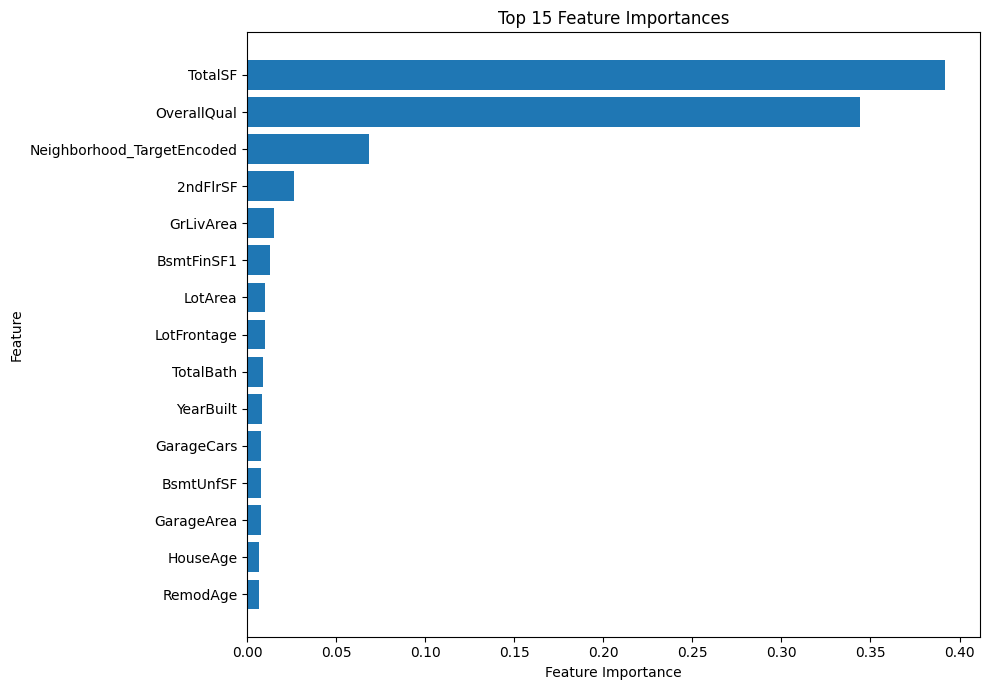

In [40]:
top_importance = feature_importance.head(15).sort_values("Importance")

plt.figure(figsize=(10, 7))
plt.barh(
    top_importance["Feature"],
    top_importance["Importance"]
)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances")
plt.tight_layout()
plt.show()

## 14. Final Feature-Engineered Model

The final model uses the features selected through Recursive Feature Elimination. This reduces the feature space while retaining variables that provide useful predictive information. The final model is evaluated using MAE, RMSE, and R² and compared with the baseline model.

In [41]:
selected_features = selected_rfe_features

X_train_final = X_train_fe[selected_features].copy()
X_test_final = X_test_fe[selected_features].copy()

# Fill missing values using training-set medians
train_medians = X_train_final.median()

X_train_final = X_train_final.fillna(train_medians)
X_test_final = X_test_final.fillna(train_medians)

print("Final features:", len(selected_features))
print("Training shape:", X_train_final.shape)
print("Testing shape:", X_test_final.shape)

Final features: 15
Training shape: (1168, 15)
Testing shape: (292, 15)


In [42]:
final_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train_final, y_train_fe)

final_predictions = final_model.predict(X_test_final)

final_mae = mean_absolute_error(y_test_fe, final_predictions)
final_rmse = np.sqrt(mean_squared_error(y_test_fe, final_predictions))
final_r2 = r2_score(y_test_fe, final_predictions)

print(f"Final MAE: {final_mae:.2f}")
print(f"Final RMSE: {final_rmse:.2f}")
print(f"Final R²: {final_r2:.4f}")

Final MAE: 17949.01
Final RMSE: 29134.48
Final R²: 0.8893


## 15. Baseline vs Final Model Comparison

The baseline and final feature-engineered models are compared using MAE, RMSE, and R². The final model achieved an MAE below the $18,000 business target. Although MAE increased slightly compared with the baseline, RMSE improved and R² increased, indicating better overall model fit.

In [43]:
comparison = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Baseline": [
        17784.5721,
        29477.2169,
        0.8867
    ],
    "Final Model": [
        17949.01,
        29134.48,
        0.8893
    ]
})

comparison

,Metric,Baseline,Final Model
0,MAE,17784.5721,17949.0100
1,RMSE,29477.2169,29134.4800
2,R²,0.8867,0.8893


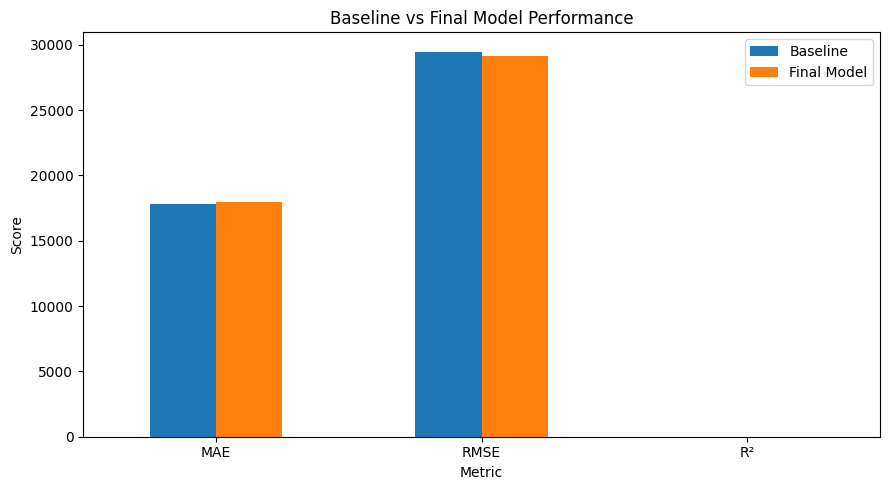

In [44]:
comparison_plot = comparison.set_index("Metric")

comparison_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Baseline vs Final Model Performance")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 16. Results and Limitations

The final feature-engineered model achieved an MAE of $17,949.01, which meets the business target of keeping MAE below $18,000. RMSE improved from $29,477.22 to $29,134.48, and R² increased from 0.8867 to 0.8893 compared with the baseline.

However, the MAE increased slightly compared with the baseline. The final model may also be affected by outliers, limited feature selection choices, and the relatively small dataset size. Further improvements could be explored using hyperparameter tuning, stronger ensemble models, and additional domain-specific features.

## 17. Business Impact

The business target was to achieve an MAE below $18,000. The final feature-engineered model achieved an MAE of $17,949.01, meeting this target. With the business scenario estimating $800K in additional annual commissions for every 5% improvement in prediction accuracy, achieving the target demonstrates that the engineered features provide useful predictive value for the real estate platform.

## 18. Conclusion

This task demonstrated an end-to-end feature engineering workflow for house price prediction. New domain-driven features, polynomial features, binning, target encoding, and multiple feature selection techniques were applied. The final model achieved an MAE of $17,949.01, meeting the business target of below $18,000. Although MAE was slightly higher than the baseline, RMSE and R² improved, showing that the engineered feature set provided useful predictive information.